<a href="https://colab.research.google.com/github/T-Svitlichna/DTA_Python/blob/main/Proekt_2_ukr/01072026_notekooks/melbourne_houses_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Melbourne Housing Snapshot

  Dataset was scraped from publicly available results posted every week from Domain.com.au
  This is intended as a static (unchanging) snapshot of https://www.kaggle.com/anthonypino/melbourne-housing-market. It was created in September 2017. Additionally, homes with no Price have been removed.

#Overview
  File informations
- melb_data.csv(2.09 MB)
- number of Rows 13580
- namber of Columns 21


#

| Column name | Description | Example Value |
|---|---|---|
| Suburb | Suburb name | Abbotsford |
| Address | Street address | 85 Turner St |
| Rooms | Number of rooms | 2 |
| Type | h = house/cottage/villa/semi/terrace · u = unit/duplex · t = townhouse · dev site = development site · o res = other residential | h, u, t |
| Price | Price in dollars | 1480000 |
| Method | See note below | S, SP, PI |
| SellerG | Real Estate Agent | Biggin |
| Date | Date sold | 3/12/2016 |
| Distance | Distance from CBD | 2.5 |
| Postcode | Postcode | 3067 |
| Bedroom2 | Scraped # of Bedrooms (from different source) | 2 |
| Bathroom | Number of Bathrooms | 1 |
| Car | Number of carspots | 1 |
| Landsize | Land Size in m² | 202 |
| BuildingArea | Building Size in m² | 126 |
| YearBuilt | Year built | 1970 |
| CouncilArea | Governing council for the area | Yarra City Council |
| Lattitude | Latitude coordinate | -37.7996 |
| Longtitude | Longitude coordinate | 144.9984 |
| Regionname | General Region (West, North West, North, North East etc.) | Northern Metropolitan |
| Propertycount | Number of properties that exist in the suburb | 4019 |

---

**Method values:**
- **S** — property sold
- **SP** — sold prior
- **PI** — passed in
- **PN** — sold prior not disclosed
- **SN** — sold not disclosed
- **NB** — no bid
- **VB** — vendor bid
- **W** — withdrawn prior to auction
- **SA** — sold after auction
- **SS** — sold after auction, price not disclosed
- **N/A** — price or highest bid not available

!pip install numpy pandas matplotlib

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
RANDOM_STATE = 42
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

FILE_IN = 'https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv'
FILE_OUT = "data/Melbourne_houses_analyse.csv"

df_origin = pd.read_csv(FILE_IN)



#Primary diagnosis

In [152]:
df_origin.head()
df = df_origin.copy()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


Problem:

Date columns (Transaction Date) as object

#Date column to date
python# Date column was loaded as a plain string (object type)


In [153]:
# We convert it to a proper datetime so we can extract year, month later
# dayfirst=True is critical — Australian date format is DD/MM/YYYY, not MM/DD/YYYY

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Dtype: {df['Date'].dtype}")

Date range: 2016-01-28 → 2017-09-23
Dtype: datetime64[ns]


Find  dirty  and Null values

In [154]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing/len(df) * 100).round(2)
missing_rep = pd.DataFrame({
    "count": missing,
    "%": missing_pct
})
#print(missing_rep)
missnotnull = missing_rep[missing_rep["%"] > 0]
print(missnotnull)

Missing values:

              count      %
Car              62   0.46
BuildingArea   6450  47.50
YearBuilt      5375  39.58
CouncilArea    1369  10.08


In [155]:
dirty = ["ERROR", "UNKNOWN", "UNK", "N/A", "?", "-", ""," " "NONE", "NULL"]

for col in ['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount']:
    count = df[col].astype(str).str.upper().isin(dirty).sum()
    nan = df[col].isna().sum()
    display(f"{col}: брудних={count}, NaN={nan}")
print("-" *29)
print("Dirty values did not find")

'Suburb: брудних=0, NaN=0'

'Address: брудних=0, NaN=0'

'Rooms: брудних=0, NaN=0'

'Type: брудних=0, NaN=0'

'Price: брудних=0, NaN=0'

...

'Lattitude: брудних=0, NaN=0'

'Longtitude: брудних=0, NaN=0'

'Regionname: брудних=0, NaN=0'

'Propertycount: брудних=0, NaN=0'

-----------------------------
Dirty values did not find


In [156]:
df.YearBuilt.sort_values().head(5)

,YearBuilt
9968,1196.0
2079,1830.0
4843,1850.0
5405,1850.0
2554,1850.0


# Передбачення площі шляхом навчання моделі

In [157]:
# КРОК 1: Відбір рядків де є площа + видалення викидів
#- підготовка окремого Датасету для моделі
df_clean = df.dropna(subset=["BuildingArea"]).copy()
before = len(df_clean)
df_clean = df_clean[(df_clean["BuildingArea"] >= 20) & (df_clean["BuildingArea"] <= 520)]
print(f"Рядків з площею: {len(df_clean)}  (мінус викидів: {before - len(df_clean)})\n")
print("% данних від основного Датасету  : ", round(len(df_clean) / len(df) * 100, 2), "%")

Рядків з площею: 6986  (мінус викидів: 144)

% данних від основного Датасету  :  51.44 %


In [158]:
# КРОК 2: Підготовка додаткових ознак YearBuilt -> Age
df_clean["YearSale"] = pd.to_datetime(df_clean["Date"], dayfirst=True).dt.year


print("Відсутніх значень YearBuilt:", df_clean.YearBuilt.isna().sum())
print("Відсутніх значень YearBuilt у %:", round(df_clean["YearBuilt"].isna().sum() / len(df_clean) * 100, 2))

Відсутніх значень YearBuilt: 224
Відсутніх значень YearBuilt у %: 3.21


In [159]:
# КРОК 3 Заповнення Медіаною пропусків з колонці "YearBuilt
# Некоректні значення YearBuilt > YearSale замінюємо на NaN
#Все потім заповняться каскадною медіаною разом з рештою пропусків
invalid = (df_clean["YearBuilt"] > df_clean["YearSale"]).sum()
df_clean.loc[df_clean["YearBuilt"] > df_clean["YearSale"], "YearBuilt"] = np.nan
print(f"Некоректних YearBuilt замінено на NaN: {invalid} (рядки збережено)")
print(f"Пропусків у YearBuilt: {df_clean['YearBuilt'].isna().sum()}")

# Каскадне заповнення: Suburb+Type -> Regionname+Type -> глобальна медіана
df_clean["YearBuilt"] = df_clean.groupby(["Suburb", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df_clean["YearBuilt"] = df_clean.groupby(["Regionname", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df_clean["YearBuilt"] = df_clean["YearBuilt"].fillna(df_clean["YearBuilt"].median())
print(f"Після заповнення: {df_clean['YearBuilt'].isna().sum()} пропусків\n")

# Перевірка коректності після заповнення
assert (df_clean["YearBuilt"] <= df_clean["YearSale"]).all(), "ПОМИЛКА: YearBuilt > YearSale!"

# Age = вік будинку на момент продажу
df_clean["Age"] = df_clean["YearSale"] - df_clean["YearBuilt"]
print(f"Age: мін={df_clean['Age'].min():.0f}, макс={df_clean['Age'].max():.0f}, медіана={df_clean['Age'].median():.0f} років\n")


Некоректних YearBuilt замінено на NaN: 6 (рядки збережено)
Пропусків у YearBuilt: 230
Після заповнення: 0 пропусків

Age: мін=0, макс=821, медіана=47 років



In [160]:
# КРОК 4: Заповнення пропусків CouncilArea
print("Відсутніх значень CouncilArea:", df_clean.CouncilArea.isna().sum())
print("Відсутніх значень CouncilArea у %:", round(df_clean["CouncilArea"].isna().sum() / len(df_clean) * 100, 2))

df_clean["CouncilArea"] = df_clean.groupby("Suburb")["CouncilArea"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
df_clean["CouncilArea"] = df_clean["CouncilArea"].fillna("Unknown")

# Ради з малою кількістю об'єктів (< 100) об'єднуємо в "Other"
# Це запобігає перевантаженню моделі рідкісними категоріями
council_counts = df_clean["CouncilArea"].value_counts()
rare_councils   = council_counts[council_counts < 100].index
df_clean["CouncilArea"] = df_clean["CouncilArea"].replace(rare_councils, "Other")
print(f"CouncilArea: {df_clean['CouncilArea'].nunique()} унікальних значень")
print(f"   (рідкісні ради < 100 об'єктів об'єднано в 'Other': {len(rare_councils)} рад)\n")
print(df_clean["CouncilArea"].value_counts())

Відсутніх значень CouncilArea: 660
Відсутніх значень CouncilArea у %: 9.45
CouncilArea: 21 унікальних значень
   (рідкісні ради < 100 об'єктів об'єднано в 'Other': 12 рад)

CouncilArea
Moreland         709
Boroondara       623
Moonee Valley    566
Darebin          471
Glen Eira        470
Maribyrnong      433
Other            396
Yarra            366
Port Phillip     359
Stonnington      357
Banyule          302
Melbourne        260
Bayside          252
Hobsons Bay      249
Brimbank         223
Monash           204
Whitehorse       177
Manningham       176
Kingston         143
Hume             139
Whittlesea       111
Name: count, dtype: int64


In [161]:
# КРОК 5: One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=["Type", "Regionname", "CouncilArea"], drop_first=True)
type_cols    = [c for c in df_encoded.columns if c.startswith("Type_")]
region_cols  = [c for c in df_encoded.columns if c.startswith("Regionname_")]
council_cols = [c for c in df_encoded.columns if c.startswith("CouncilArea_")]
print(f"One-Hot Encoding: {len(type_cols)} Type + {len(region_cols)} Regionname + {len(council_cols)} CouncilArea\n")

One-Hot Encoding: 2 Type + 7 Regionname + 20 CouncilArea



In [162]:
# КРОК 6: Формування ознак
numeric_features = ["Rooms", "Bedroom2", "Bathroom", "Car",
                    "Landsize", "Distance", "Propertycount", "Age"]
features = numeric_features + type_cols + region_cols + council_cols
target   = "BuildingArea"

df_model = df_encoded[features + [target]].dropna()
print(f"Всього ознак: {len(features)}  |  Рядків: {len(df_model)}\n")

Всього ознак: 37  |  Рядків: 6957



In [163]:

# КРОК 7: Розбиття 80/20
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Навчання: {len(X_train)}  |  Тест: {len(X_test)}\n")

Навчання: 5565  |  Тест: 1392



In [164]:
# КРОК 8: Три моделі через Pipeline -  приводить всі числові ознаки до єдиної шкали за формулою:
# = (значення - середнє значення) / стандартне_відхилення)
from sklearn.pipeline import Pipeline


# Pipeline автоматично застосовує scaler перед кожною моделлю

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe_gb = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                          max_depth=5, random_state=42))
])

# fit і predict — масштабування відбувається автоматично всередині
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
r2_rf  = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

pipe_gb.fit(X_train, y_train)
y_pred_gb = pipe_gb.predict(X_test)
r2_gb  = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

In [165]:


print("-" * 55)
print("  РЕЗУЛЬТАТИ ")
print("-" * 55)
print("\n  Лінійна регресія:")
print(f"    R2  = {r2_lr:.4f}  ({r2_lr*100:.1f}%)")
print(f"    MAE = {mae_lr:.1f} м2")
print(f"\n  Random Forest:")
print(f"    R2  = {r2_rf:.4f}  ({r2_rf*100:.1f}%)")
print(f"    MAE = {mae_rf:.1f} м2")
print(f"\n  Gradient Boosting:")
print(f"    R2  = {r2_gb:.4f}  ({r2_gb*100:.1f}%)")
print(f"    MAE = {mae_gb:.1f} м2")
print("=" * 55)
print("  Для порівняння v5: GB R2=0.715 | MAE=24.3 м2")
print("=" * 55)

-------------------------------------------------------
  РЕЗУЛЬТАТИ 
-------------------------------------------------------

  Лінійна регресія:
    R2  = 0.6699  (67.0%)
    MAE = 27.7 м2

  Random Forest:
    R2  = 0.6952  (69.5%)
    MAE = 25.1 м2

  Gradient Boosting:
    R2  = 0.7140  (71.4%)
    MAE = 24.3 м2
  Для порівняння v5: GB R2=0.715 | MAE=24.3 м2


# Для imput ми обираємо Gradient Boosting із значенням : R²  = 0.7140 (71.4%) та MAE = 24.3 м2

In [166]:

# ════════════════════════════════════════════════════════
# БЛОК 2: ЧЕК-ЛИСТ оригінального датасету
# ════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  ЧЕК-ЛИСТ: некоректні значення в оригінальному df")
print("=" * 55)

checks = [
    ("Price <= 0",           (df["Price"] <= 0).sum()),
    ("Rooms <= 0",           (df["Rooms"] <= 0).sum()),
    ("Bedroom2 < 0",         (df["Bedroom2"] < 0).sum()),
    ("Bathroom < 0",         (df["Bathroom"] < 0).sum()),
    ("Car < 0",              (df["Car"] < 0).sum()),
    ("Landsize < 0",         (df["Landsize"] < 0).sum()),
    ("BuildingArea <= 0",    (df["BuildingArea"].notna() & (df["BuildingArea"] <= 0)).sum()),
    ("Distance < 0",         (df["Distance"] < 0).sum()),
    ("YearBuilt нереальний", (df["YearBuilt"].notna() & ((df["YearBuilt"] < 1800) | (df["YearBuilt"] > 2025))).sum()),
    ("Bedroom2 > Rooms",     (df["Bedroom2"].notna() & (df["Bedroom2"] > df["Rooms"])).sum()),
]

for label, count in checks:
    status = "OK" if count == 0 else f"! {count} записів"
    print(f"  {label:<30}: {status}")

print("=" * 55)
df["Car"] = df["Car"].fillna(0)
print(f"Car: пропуски заповнено нулями, залишилось NaN: {df['Car'].isna().sum()}")

# ════════════════════════════════════════════════════════
# БЛОК 3: ЗАПОВНЕННЯ ТІЛЬКИ BuildingArea через pipe_gb
# Оригінальний df — без змін, викиди збережено
# ════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("  ЗАПОВНЕННЯ ПРОПУСКІВ BuildingArea")
print("=" * 55)

# Готуємо ознаки для ПОВНОГО датасету (так само як для моделі)
df_work = df.copy()
df_work["YearSale"] = pd.to_datetime(df_work["Date"], dayfirst=True).dt.year

df_work.loc[df_work["YearBuilt"] > df_work["YearSale"], "YearBuilt"] = np.nan
df_work["YearBuilt"] = df_work.groupby(["Suburb", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df_work["YearBuilt"] = df_work.groupby(["Regionname", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df_work["YearBuilt"] = df_work["YearBuilt"].fillna(df_work["YearBuilt"].median())
df_work["Age"] = df_work["YearSale"] - df_work["YearBuilt"]

df_work["CouncilArea"] = df_work.groupby("Suburb")["CouncilArea"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))
df_work["CouncilArea"] = df_work["CouncilArea"].fillna("Unknown")
df_work["CouncilArea"] = df_work["CouncilArea"].replace(rare_councils, "Other")

# One-Hot Encoding з тими самими колонками що і в моделі
df_work_encoded = pd.get_dummies(df_work, columns=["Type", "Regionname", "CouncilArea"], drop_first=True)

# Вирівнюємо колонки — модель очікує точно такий самий набір
df_work_encoded = df_work_encoded.reindex(columns=df_encoded.columns, fill_value=0)

# Рядки де BuildingArea відсутня і є всі потрібні ознаки
mask_predict  = df_work_encoded[target].isna()
df_to_predict = df_work_encoded[mask_predict].dropna(subset=features)

print(f"Пропусків у BuildingArea: {mask_predict.sum()}")
print(f"Можемо заповнити:         {len(df_to_predict)} рядків")
print(f"Бракує ознак для:         {mask_predict.sum() - len(df_to_predict)} рядків\n")


# Підставляємо ТІЛЬКИ BuildingArea в оригінальний df
df_result = df.copy()
df_result.loc[df_to_predict.index, "BuildingArea"] = predicted

print(f"  До заповнення:    {df['BuildingArea'].isna().sum()} пропусків")
print(f"  Після заповнення: {df_result['BuildingArea'].isna().sum()} пропусків")
print(f"  Всі інші колонки — без змін, викиди збережено")
print("=" * 55)

df_result.to_csv("Melbourne_housing_filled.csv", index=False)
print("\nДатасет збережено: Melbourne_housing_filled.csv")
print(f"Розмір: {df_result.shape[0]} x {df_result.shape[1]}")


  ЧЕК-ЛИСТ: некоректні значення в оригінальному df
  Price <= 0                    : OK
  Rooms <= 0                    : OK
  Bedroom2 < 0                  : OK
  Bathroom < 0                  : OK
  Car < 0                       : OK
  Landsize < 0                  : OK
  BuildingArea <= 0             : ! 17 записів
  Distance < 0                  : OK
  YearBuilt нереальний          : ! 1 записів
  Bedroom2 > Rooms              : ! 203 записів
Car: пропуски заповнено нулями, залишилось NaN: 0

  ЗАПОВНЕННЯ ПРОПУСКІВ BuildingArea
Пропусків у BuildingArea: 6450
Можемо заповнити:         6450 рядків
Бракує ознак для:         0 рядків

  До заповнення:    6450 пропусків
  Після заповнення: 0 пропусків
  Всі інші колонки — без змін, викиди збережено

Датасет збережено: Melbourne_housing_filled.csv
Розмір: 13580 x 21


In [167]:

# БЛОК 3: Додавання нових ознак до повного df



# YearSale — рік продажу з Date
df["YearSale"] = pd.to_datetime(df["Date"], dayfirst=True).dt.year

# YearBuilt: некоректні > YearSale -> NaN (вже зроблено в Блоці 2)
# Каскадна медіана: Suburb+Type -> Regionname+Type -> глобальна
df["YearBuilt"] = df.groupby(["Suburb", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df["YearBuilt"] = df.groupby(["Regionname", "Type"])["YearBuilt"].transform(
    lambda x: x.fillna(x.median()))
df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())

# Age = вік будинку на момент продажу
df["Age"] = df["YearSale"] - df["YearBuilt"]

# CouncilArea: рідкісні ради (< 50 об'єктів) -> "Other"
df["CouncilArea"] = df["CouncilArea"].replace(rare_councils, "Other")

print(f"Нові ознаки додано: YearSale, Age")
print(f"CouncilArea: рідкісні -> Other")
print(f"Розмір df: {df.shape[0]} x {df.shape[1]}")
print(f"BuildingArea NaN: {df['BuildingArea'].isna().sum()} (залишено як є)")

df.to_csv("Melbourne_housing_final.csv", index=False)
print(f"\nДатасет збережено: Melbourne_housing_final.csv")

Нові ознаки додано: YearSale, Age
CouncilArea: рідкісні -> Other
Розмір df: 13580 x 23
BuildingArea NaN: 6450 (залишено як є)

Датасет збережено: Melbourne_housing_final.csv


In [168]:
# One-Hot Encoding — вирівнюємо під модель
df_work_encoded = pd.get_dummies(df, columns=["Type", "Regionname", "CouncilArea"], drop_first=True)
df_work_encoded = df_work_encoded.reindex(columns=df_encoded.columns, fill_value=0)

# Рядки де BuildingArea відсутня і є всі потрібні ознаки
mask_predict  = df_work_encoded[target].isna()
df_to_predict = df_work_encoded[mask_predict].dropna(subset=features)

print(f"Пропусків у BuildingArea: {mask_predict.sum()}")
print(f"Можемо заповнити:         {len(df_to_predict)} рядків")
print(f"Залишиться NaN:           {mask_predict.sum() - len(df_to_predict)} рядків\n")

# Прогноз через pipe_gb
predicted = pipe_gb.predict(df_to_predict[features])
predicted = np.clip(predicted, 5, 1200)

print(f"Прогноз: мін={predicted.min():.1f}, макс={predicted.max():.1f}, медіана={np.median(predicted):.1f} м2")

# Підставляємо ТІЛЬКИ BuildingArea
df.loc[df_to_predict.index, "BuildingArea"] = predicted


Пропусків у BuildingArea: 6450
Можемо заповнити:         6450 рядків
Залишиться NaN:           0 рядків

Прогноз: мін=32.7, макс=456.4, медіана=124.2 м2


In [169]:
df.to_csv("Melbourne_housing_final.csv", index=False)
print(f"Датасет збережено: Melbourne_housing_final.csv  ({df.shape[0]} x {df.shape[1]})")
print(f"BuildingArea NaN: {df['BuildingArea'].isna().sum()}")

Датасет збережено: Melbourne_housing_final.csv  (13580 x 23)
BuildingArea NaN: 0


# 11 Cheak

#Крок 4. Дослідження (EDA)

розподіл цілі Price (

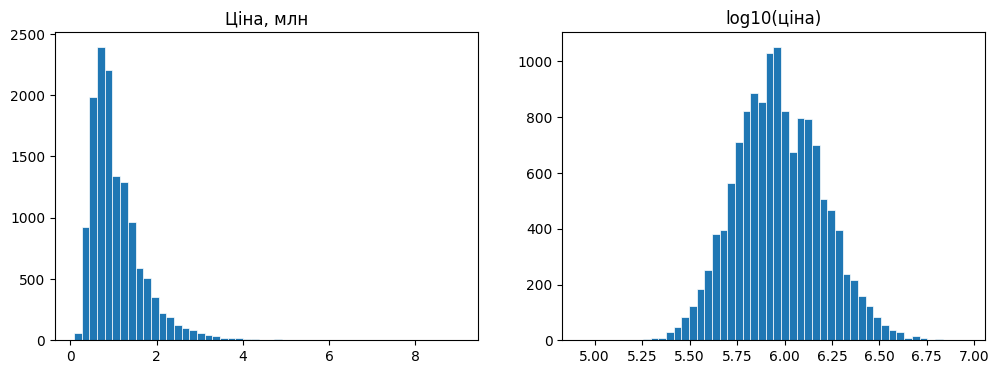

In [171]:

clean2 = df.copy()

if "Unnamed: 0" in clean2.columns:
    clean2 = clean2.drop(columns=["Unnamed: 0"])


fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(clean2["Price"] / 1e6, bins=50, edgecolor='white', linewidth=0.5)
ax[0].set_title("Ціна, млн")

ax[1].hist(np.log10(clean2["Price"]), bins=50, edgecolor='white', linewidth=0.5)
ax[1].set_title("log10(ціна)")

plt.show()

як ціна залежить від типу житла та району;

In [172]:
df_ztype = df.groupby(['Type'])['Price'].mean().sort_values(ascending=False)/1000
df_ztype.round(1)

,Price
Type,
h,1242.7
t,933.7
u,605.1


зв'язок числових ознак із ціною (кореляції)

In [173]:
corr2 = df.select_dtypes(include='number').corr()['Price'].drop('Price').sort_values()
print(corr2.round(2))

YearBuilt       -0.35
Lattitude       -0.21
Distance        -0.16
Propertycount   -0.04
YearSale         0.00
Landsize         0.04
BuildingArea     0.10
Postcode         0.11
Longtitude       0.20
Car              0.23
Age              0.35
Bathroom         0.47
Bedroom2         0.48
Rooms            0.50
Name: Price, dtype: float64


чи немає пар ознак, які майже дублюють одна одну

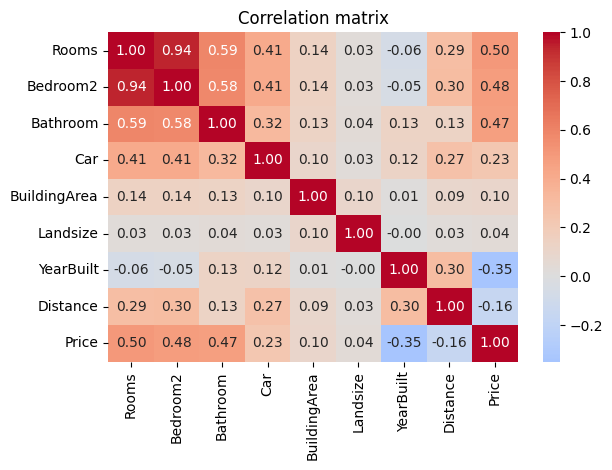

In [184]:
import seaborn as sns

cols = ['Rooms', 'Bedroom2', 'Bathroom', 'Car', 'BuildingArea', 'Landsize', 'YearBuilt', 'Distance', 'Price']

sns.heatmap(df[cols].corr().round(2), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

 #Крок 5. Нові ознаки (feature engineering) вік будинку, залежність району від віддаленості від центру


In [185]:
df['Sale_month']    = df['Date'].dt.month
df['Build_density'] = df['BuildingArea'] / (df['Landsize'] + 1)

print(df[['Age', 'Sale_month', 'Build_density']].describe().round(2))

            Age  Sale_month  Build_density
count  13580.00    13580.00       13580.00
mean      54.43        7.05          12.17
std       34.17        2.54          35.68
min       -2.00        1.00           0.00
25%       29.38        5.00           0.22
50%       51.00        7.00           0.36
75%       76.00        9.00           0.67
max      821.00       12.00        1561.00


2

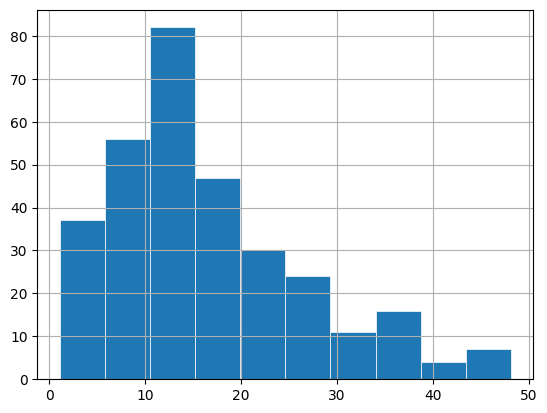

In [186]:
sub_dis = df.groupby('Suburb')['Distance'].mean().sort_values()
sub_dis.describe()
s = sub_dis.hist(bins=10, edgecolor='white', linewidth=0.5)
plt.show()

In [187]:
# Distance zone — ordinal feature based on distance from CBD
# 1 = closest, 10 = furthest
df['Distance_zone'] = pd.cut(df['Distance'], bins=10, labels=range(1, 11)).astype(int)

print(df['Distance_zone'].value_counts().sort_index())

Distance_zone
1     2212
2     4789
3     4533
4     1207
5      440
6      166
7      103
8      104
9        9
10      17
Name: count, dtype: int64


In [197]:
# МОДЕЛЬ: Прогнозування ціни (Price)

# Відбір рядків де є ціна + One-Hot Encoding
df_price = pd.get_dummies(df.dropna(subset=["Price"]).copy(),
                          columns=["Type", "Regionname", "CouncilArea"], drop_first=True)

type_cols_p    = [c for c in df_price.columns if c.startswith("Type_")]
region_cols_p  = [c for c in df_price.columns if c.startswith("Regionname_")]
council_cols_p = [c for c in df_price.columns if c.startswith("CouncilArea_")]

features_price = ["Rooms",  "Bathroom", "Car", "Landsize",'Build_density','Sale_month',
                  "Distance", "Propertycount", "Age", "BuildingArea"] \
               + type_cols_p + region_cols_p + council_cols_p

df_pm = df_price[features_price + ["Price"]].dropna()
print(f"Ознак: {len(features_price)}  |  Рядків: {len(df_pm)}\n")

X_train, X_test, y_train, y_test = train_test_split(
    df_pm[features_price], df_pm["Price"], test_size=0.2, random_state=42)

# Три моделі
pipe_lr_p = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_rf_p = Pipeline([("scaler", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
pipe_gb_p = Pipeline([("scaler", StandardScaler()), ("model", GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42))])

pipe_lr_p.fit(X_train, y_train)
y_pred_lr_p = pipe_lr_p.predict(X_test)
print("Лінійна регресія R2=", round(r2_score(y_test, y_pred_lr_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_lr_p), 0), "$")

pipe_rf_p.fit(X_train, y_train)
y_pred_rf_p = pipe_rf_p.predict(X_test)
print("Random Forest R2=", round(r2_score(y_test, y_pred_rf_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_rf_p), 0), "$")

pipe_gb_p.fit(X_train, y_train)
y_pred_gb_p = pipe_gb_p.predict(X_test)
print("Gradient Boosting R2=", round(r2_score(y_test, y_pred_gb_p), 4), "MAE=", round(mean_absolute_error(y_test, y_pred_gb_p), 0), "$")

# Топ-10 ознак кращої моделі (Gradient Boosting)
y_pred_gb_p = pipe_gb_p.predict(X_test)
importances_p = pd.Series(pipe_gb_p.named_steps["model"].feature_importances_,
                           index=features_price).sort_values(ascending=False)
print(f"\nТоп-10 ознак (Gradient Boosting):")
for feat, imp in importances_p.head(10).items():
    print(f"   {feat:<35}: {imp:.4f}")

Ознак: 41  |  Рядків: 13580

Лінійна регресія R2= 0.6358 MAE= 258861.0 $
Random Forest R2= 0.7954 MAE= 176824.0 $
Gradient Boosting R2= 0.8138 MAE= 169866.0 $

Топ-10 ознак (Gradient Boosting):
   BuildingArea                       : 0.3699
   Regionname_Southern Metropolitan   : 0.1602
   Age                                : 0.1517
   Distance                           : 0.1031
   Landsize                           : 0.0543
   Build_density                      : 0.0241
   Bathroom                           : 0.0238
   Rooms                              : 0.0230
   Propertycount                      : 0.0181
   Type_u                             : 0.0150


In [194]:
from sklearn.dummy import DummyRegressor
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
y_base = baseline.predict(X_test)
print(f"Baseline MAE={mean_absolute_error(y_test, y_base):,.0f} $")
print(f"Baseline R2={r2_score(y_test, y_base):.4f}")

Baseline MAE=461,258 $
Baseline R2=-0.0000


In [195]:
# Один рядок з тестової вибірки
example = X_test.iloc[[0]]
real_price = y_test.iloc[0]
predicted = pipe_gb_p.predict(example)[0]
print(f"Реальна ціна: {real_price:,.0f} $")
print(f"Прогноз:      {predicted:,.0f} $")
print(f"Похибка:      {abs(real_price - predicted):,.0f} $")

Реальна ціна: 2,600,000 $
Прогноз:      1,971,817 $
Похибка:      628,183 $


In [183]:
df.shape

(13580, 26)

https://raw.githubusercontent.com/T-Svitlichna/Melbourne_housing/refs/heads/main/data/melb_data.csv